In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
#preprocess MRI images
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [3]:
#get train and test folders
train_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/madonnaashraf/dlproject/brain tumar/Training",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/madonnaashraf/dlproject/brain tumar/Testing",
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

num_classes=4

In [4]:
#classes
print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
class DenseLayer(nn.Module):

    def __init__(self, in_channels, growth_rate):
        super().__init__()

        self.layer = nn.Sequential(

            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, growth_rate, kernel_size=1, padding=0),

            nn.BatchNorm2d(growth_rate),
            nn.ReLU(),
            nn.Conv2d(growth_rate, growth_rate, kernel_size=3, padding=1)
        )

    def forward(self, x):
        out = self.layer(x)
        return torch.cat([x, out], dim=1)

In [9]:
#simple denseNet
class DenseNet(nn.Module):
    def __init__(self,num_classes=4):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            DenseLayer(32,16),
            DenseLayer(48,16),
            DenseLayer(64,16),

            nn.MaxPool2d(2),

            DenseLayer(80,16),
            DenseLayer(96,16),
            DenseLayer(112,16),

            nn.MaxPool2d(2),

            DenseLayer(128,16),
            DenseLayer(144,16),

            nn.BatchNorm2d(160),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(160,num_classes)

    def forward(self,x):
        x=self.features(x)
        x=torch.flatten(x,1)
        x=self.dropout(x)
        x=self.fc(x)
        return x

In [10]:
device="cuda" if torch.cuda.is_available() else "cpu"
model=DenseNet(4).to(device)

In [11]:
lossfn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=2,gamma=0.5)

In [12]:
# Train
e = 30
train_losses = []
test_losses = []

for epoch in range(e):
    model.train()
    total_loss = []
    correct = 0
    total = 0

    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        loss = lossfn(out,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss.append(loss.item())
        _,pred = torch.max(out,1)
        total += labels.size(0)
        correct += (pred==labels).sum().item()

    scheduler.step()

    avg_loss = sum(total_loss)/len(total_loss)
    train_losses.append(avg_loss)
    acc = 100 * correct / total

    print(f"epoch[{epoch+1}]")
    print(f"Train loss:{avg_loss:.4f}")
    print(f"Train accuracy:{acc:.2f}%")

   
    #TEST
   
    model.eval()

    correct = 0
    total = 0
    total_test_loss = []

    with torch.no_grad():

        for images,labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outs = model(images)
            
            loss = lossfn(outs,labels)
            total_test_loss.append(loss.item())
            _,pred = torch.max(outs,1)
            total += labels.size(0)
            correct += (pred==labels).sum().item()

    avg_test_loss = sum(total_test_loss)/len(total_test_loss)
    test_losses.append(avg_test_loss)
    test_acc = 100 * correct / total

    print(f"Test loss: {avg_test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.2f}%")

    print("-"*40)

epoch[1]
Train loss:1.1597
Train accuracy:54.32%
Test loss: 1.1043
Test accuracy: 59.50%
----------------------------------------
epoch[2]
Train loss:0.9814
Train accuracy:65.41%
Test loss: 1.0387
Test accuracy: 59.50%
----------------------------------------
epoch[3]
Train loss:0.9112
Train accuracy:67.32%
Test loss: 1.0084
Test accuracy: 61.56%
----------------------------------------
epoch[4]
Train loss:0.8713
Train accuracy:69.30%
Test loss: 0.9881
Test accuracy: 61.94%
----------------------------------------
epoch[5]
Train loss:0.8394
Train accuracy:70.55%
Test loss: 0.9698
Test accuracy: 62.81%
----------------------------------------
epoch[6]
Train loss:0.8227
Train accuracy:71.07%
Test loss: 0.9701
Test accuracy: 62.69%
----------------------------------------
epoch[7]
Train loss:0.8143
Train accuracy:71.50%
Test loss: 0.9607
Test accuracy: 62.50%
----------------------------------------
epoch[8]
Train loss:0.8100
Train accuracy:71.45%
Test loss: 0.9512
Test accuracy: 62.62%
-

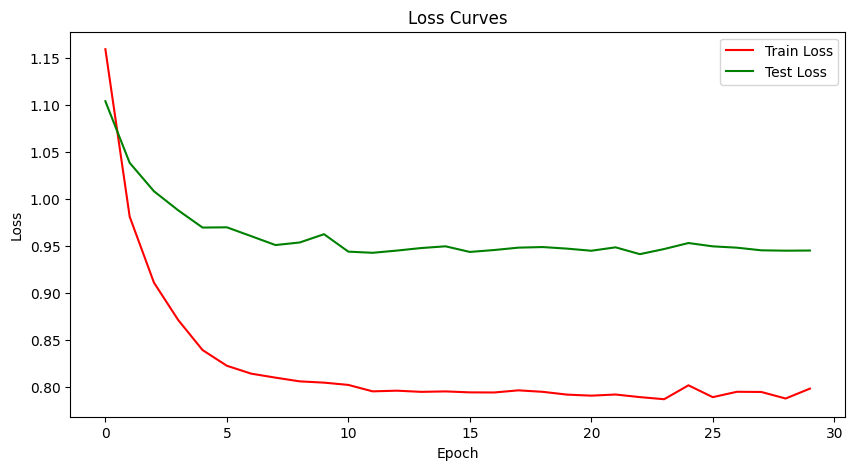

In [13]:
plt.figure(figsize=(10,5))
plt.plot(train_losses,label="Train Loss",color="red")
plt.plot(test_losses,label="Test Loss",color="green")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")

plt.legend()
plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

              precision    recall  f1-score   support

      glioma       0.53      0.62      0.57       400
  meningioma       0.54      0.24      0.33       400
     notumor       0.69      0.86      0.77       400
   pituitary       0.72      0.80      0.76       400

    accuracy                           0.63      1600
   macro avg       0.62      0.63      0.61      1600
weighted avg       0.62      0.63      0.61      1600



In [16]:
#denseBlock
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()

        layers = []

        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)



In [17]:
#transition layer
class Transition(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.transition = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.transition(x)

In [28]:
#denseNet121
class DenseNet121(nn.Module):

    def __init__(self, num_classes=4, growth_rate=32):
        super().__init__()

        # Initial conv
        self.init = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        # Dense Blocks configuration for DenseNet121
        self.block1 = DenseBlock(6, 64, growth_rate)
        self.trans1 = Transition(64 + 6 * growth_rate, 128)

        self.block2 = DenseBlock(12, 128, growth_rate)
        self.trans2 = Transition(128 + 12 * growth_rate, 256)

        self.block3 = DenseBlock(24, 256, growth_rate)
        self.trans3 = Transition(256 + 24 * growth_rate, 512)

        self.block4 = DenseBlock(16, 512, growth_rate)

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.4)
        self.classifier = nn.Linear(512 + 16 * growth_rate, num_classes)

    def forward(self, x):

        x = self.init(x)

        x = self.block1(x)
        x = self.trans1(x)

        x = self.block2(x)
        x = self.trans2(x)

        x = self.block3(x)
        x = self.trans3(x)

        x = self.block4(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [29]:
device="cuda" if torch.cuda.is_available() else "cpu"
model=DenseNet121(4,).to(device)

In [30]:
lossfn=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5,patience=2)

In [31]:
# Train
e = 20
train_losses = []
test_losses = []

for epoch in range(e):
    model.train()
    total_loss = []
    correct = 0
    total = 0

    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        loss = lossfn(out,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss.append(loss.item())
        _,pred = torch.max(out,1)
        total += labels.size(0)
        correct += (pred==labels).sum().item()

    scheduler.step(avg_test_loss)

    avg_loss = sum(total_loss)/len(total_loss)
    train_losses.append(avg_loss)
    acc = 100 * correct / total

    print(f"epoch[{epoch+1}]")
    print(f"Train loss:{avg_loss:.4f}")
    print(f"Train accuracy:{acc:.2f}%")

   
    #TEST
   
    model.eval()

    correct = 0
    total = 0
    total_test_loss = []

    with torch.no_grad():

        for images,labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outs = model(images)
            
            loss = lossfn(outs,labels)
            total_test_loss.append(loss.item())
            _,pred = torch.max(outs,1)
            total += labels.size(0)
            correct += (pred==labels).sum().item()

    avg_test_loss = sum(total_test_loss)/len(total_test_loss)
    test_losses.append(avg_test_loss)
    test_acc = 100 * correct / total

    print(f"Test loss: {avg_test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.2f}%")

    print("-"*40)

epoch[1]
Train loss:0.6438
Train accuracy:75.20%
Test loss: 0.7860
Test accuracy: 70.62%
----------------------------------------
epoch[2]
Train loss:0.3532
Train accuracy:86.96%
Test loss: 0.6349
Test accuracy: 80.19%
----------------------------------------
epoch[3]
Train loss:0.2797
Train accuracy:90.12%
Test loss: 0.6703
Test accuracy: 77.06%
----------------------------------------
epoch[4]
Train loss:0.1999
Train accuracy:93.05%
Test loss: 1.0458
Test accuracy: 75.19%
----------------------------------------
epoch[5]
Train loss:0.1684
Train accuracy:93.89%
Test loss: 0.9694
Test accuracy: 76.38%
----------------------------------------
epoch[6]
Train loss:0.1366
Train accuracy:95.14%
Test loss: 0.6351
Test accuracy: 86.62%
----------------------------------------
epoch[7]
Train loss:0.0714
Train accuracy:97.66%
Test loss: 0.4581
Test accuracy: 89.88%
----------------------------------------
epoch[8]
Train loss:0.0457
Train accuracy:98.68%
Test loss: 0.5198
Test accuracy: 91.06%
-

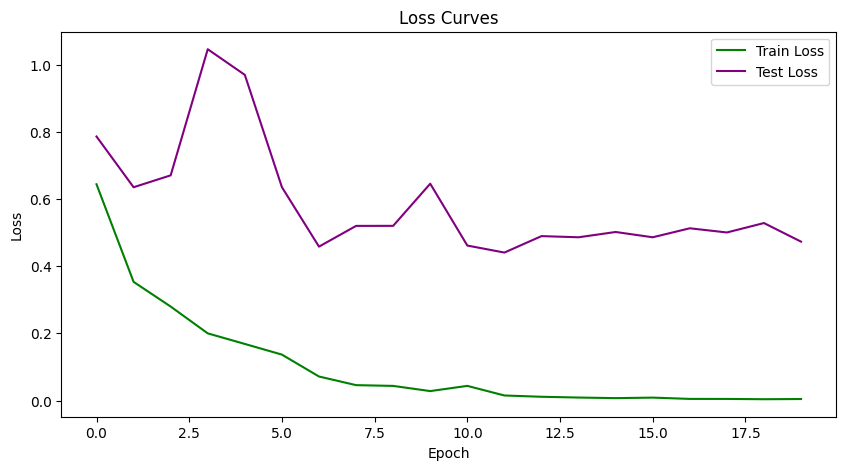

In [34]:
plt.figure(figsize=(10,5))
plt.plot(train_losses,label="Train Loss",color="green")
plt.plot(test_losses,label="Test Loss",color="purple")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")

plt.legend()
plt.show()

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.89      0.95      0.92       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600

